In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ── UNIVERSAL CELL 0 ──────────────────────────────────────────────
# It mounts Drive, loads all splits, and builds CONFIG.

from google.colab import drive
import os, json, sys
import pandas as pd

drive.mount('/content/drive', force_remount=False)

BASE = '/content/drive/MyDrive/MedSSL_Research'
assert os.path.exists(BASE), f'Drive folder not found: {BASE}'

# Load master dataframe (created by Notebook 1)
df = pd.read_csv(f'{BASE}/splits/master_dataframe.csv')

# Load official splits — NEVER regenerate these
train_idx = json.load(open(f'{BASE}/splits/train_indices.json'))
val_idx   = json.load(open(f'{BASE}/splits/val_indices.json'))
test_idx  = json.load(open(f'{BASE}/splits/test_indices.json'))
sub10_idx = json.load(open(f'{BASE}/splits/subset_10pct_seed42.json'))
sub20_idx = json.load(open(f'{BASE}/splits/subset_20pct_seed42.json'))

CLASS_NAMES = sorted(df['label_name'].unique().tolist())
NUM_CLASSES = len(CLASS_NAMES)  # should be 6

# Load helper files from Drive
sys.path.insert(0, BASE)
import importlib.util
def load_from_drive(filename, module_name):
    spec = importlib.util.spec_from_file_location(
        module_name, f'{BASE}/{filename}')
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod

aug = load_from_drive('augmentations.py', 'augmentations')
dc  = load_from_drive('dataset_class.py', 'dataset_class')
MedicalImageDataset         = dc.MedicalImageDataset
SUPERVISED_TRAIN_TRANSFORMS = aug.SUPERVISED_TRAIN_TRANSFORMS
SUPERVISED_VAL_TRANSFORMS   = aug.SUPERVISED_VAL_TRANSFORMS
SSL_PRETRAIN_TRANSFORMS     = aug.SSL_PRETRAIN_TRANSFORMS

CONFIG = {
    'base':          BASE,
    'data_dir':      f'{BASE}/dataset/processed',
    'splits_dir':    f'{BASE}/splits',
    'ckpt_dir':      f'{BASE}/checkpoints',
    'results_dir':   f'{BASE}/results',
    'figures_dir':   f'{BASE}/figures',
    'num_classes':   NUM_CLASSES,
    'class_names':   CLASS_NAMES,
    'seed':          42,
    'seeds':         [42, 123, 456],
    'batch_size':    32,
    'epochs':        50,
    'early_stop':    10,
    'lr_backbone':   1e-4,
    'lr_head':       1e-3,
    'weight_decay':  1e-4,
    'use_amp':       True,
    'image_size':    224,
    'subsets': {'10pct': sub10_idx, '20pct': sub20_idx, '100pct': train_idx},
}

os.makedirs(CONFIG['results_dir'], exist_ok=True)
os.makedirs(CONFIG['figures_dir'], exist_ok=True)

print(f'Drive: OK | Classes: {NUM_CLASSES} | ',
      f'Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive: OK | Classes: 6 |  Train: 12591 | Val: 1799 | Test: 3598


### Import all Important Libraries

In [3]:

import subprocess, sys

def pip_silent(pkgs):
    subprocess.run([sys.executable, '-m', 'pip', 'install', '--quiet'] + pkgs,
                   capture_output=True)

pip_silent(['torch', 'torchvision', 'timm', 'numpy', 'pandas',
            'scikit-learn', 'matplotlib', 'seaborn', 'tqdm'])

import torch
import torch.nn as nn
import torchvision.models as tvm
import timm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader
from sklearn.metrics import (f1_score, accuracy_score, roc_auc_score,
                              confusion_matrix, roc_curve)
from sklearn.preprocessing import label_binarize
import json, os, random, time, copy
from tqdm.notebook import tqdm

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

print()
print('=' * 55)
print('  CELL 1 COMPLETE — libraries ready')
print('=' * 55)

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB

  CELL 1 COMPLETE — libraries ready


### Model Factory

In [4]:
def build_model(model_name: str, num_classes: int):
    """
    Build a classification model and split its parameters into
    backbone and head groups for differential learning rates.

    Parameters
    ----------
    model_name  : str  — one of:
        'resnet50_pretrained', 'resnet50_scratch',
        'efficientnet_b0', 'mobilevit_xs'
    num_classes : int  — number of output classes

    Returns
    -------
    model         : nn.Module
    backbone_params : list of Parameter  (use lr_backbone)
    head_params     : list of Parameter  (use lr_head)
        For resnet50_scratch both lists contain all params
        (single-group training, no differential LR needed).
    """

    if model_name == 'resnet50_pretrained':
        model = tvm.resnet50(weights=tvm.ResNet50_Weights.IMAGENET1K_V1)
        model.fc = nn.Linear(2048, num_classes)
        backbone_params = [p for n, p in model.named_parameters() if 'fc' not in n]
        head_params     = list(model.fc.parameters())

    elif model_name == 'resnet50_scratch':
        model = tvm.resnet50(weights=None)
        model.fc = nn.Linear(2048, num_classes)
        # No differential LR for scratch — single group
        backbone_params = list(model.parameters())
        head_params     = list(model.parameters())   # same ref, handled in train_model

    elif model_name == 'efficientnet_b0':
        model = timm.create_model('efficientnet_b0', pretrained=True,
                                  num_classes=num_classes)
        classifier_names = {'classifier'}
        backbone_params = [p for n, p in model.named_parameters()
                           if not n.startswith('classifier')]
        head_params     = list(model.classifier.parameters())

    elif model_name == 'mobilevit_xs':
        # MobileViT-XS: 5.6M params, hybrid CNN + ViT architecture.
        # Local spatial conv for low-level features + global self-attention
        # for long-range dependencies. Enables CNN vs ViT comparison
        # in low-label regimes on a single T4 GPU.
        model = timm.create_model('mobilevit_xs', pretrained=True,
                                  num_classes=num_classes)
        head_names = {'head', 'classifier'}
        backbone_params = [p for n, p in model.named_parameters()
                           if not any(h in n for h in head_names)]
        head_params     = [p for n, p in model.named_parameters()
                           if any(h in n for h in head_names)]
        if len(head_params) == 0:
            # fallback: timm may name it differently
            head_params = list(model.head.parameters()) if hasattr(model, 'head') \
                          else list(model.parameters())

    else:
        raise ValueError(f'Unknown model_name: {model_name}')

    total = sum(p.numel() for p in model.parameters()) / 1e6
    print(f'  {model_name:<28}  {total:.1f}M params  '
          f'backbone_p={sum(p.numel() for p in backbone_params)/1e6:.1f}M  '
          f'head_p={sum(p.numel() for p in head_params)/1e6:.1f}M')

    return model, backbone_params, head_params


# Quick build test
print('Model factory check:')
for mn in ['resnet50_pretrained', 'resnet50_scratch', 'efficientnet_b0', 'mobilevit_xs']:
    m, bp, hp = build_model(mn, CONFIG['num_classes'])
    del m

print()
print('=' * 55)
print('  CELL 2 COMPLETE — model factory verified')
print('=' * 55)

Model factory check:
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 113MB/s]


  resnet50_pretrained           23.5M params  backbone_p=23.5M  head_p=0.0M
  resnet50_scratch              23.5M params  backbone_p=23.5M  head_p=23.5M


model.safetensors: reconstructing file:   0%|          |  0.00B / 21.4MB            

model.safetensors: downloading bytes:           |  0.00B            

  efficientnet_b0               4.0M params  backbone_p=4.0M  head_p=0.0M


model.safetensors: reconstructing file:   0%|          |  0.00B / 9.34MB            

model.safetensors: downloading bytes:           |  0.00B            

  mobilevit_xs                  1.9M params  backbone_p=1.9M  head_p=0.0M

  CELL 2 COMPLETE — model factory verified


### Training Engine

In [5]:
# ── Seed ─────────────────────────────────────────────────────
def set_seed(seed: int) -> None:
    """Set all random seeds for full reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False


# ── ECE ──────────────────────────────────────────────────────
def compute_ece(probs: np.ndarray, labels: np.ndarray, n_bins: int = 15) -> float:
    """
    Expected Calibration Error (15-bin).

    Parameters
    ----------
    probs  : np.ndarray (N, C)  softmax probabilities
    labels : np.ndarray (N,)    integer ground-truth labels
    n_bins : int                number of equal-width confidence bins

    Returns
    -------
    float  ECE in [0, 1]
    """
    confidences = probs.max(axis=1)
    predictions = probs.argmax(axis=1)
    correct     = (predictions == labels).astype(float)
    bin_edges   = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
        mask = (confidences >= lo) & (confidences < hi)
        if mask.sum() == 0:
            continue
        ece += mask.sum() * abs(confidences[mask].mean() - correct[mask].mean())
    return float(ece / max(len(labels), 1))


# ── Bootstrap AUC  (FIXED) ───────────────────────────────────
def bootstrap_auc(y_true: np.ndarray, y_prob: np.ndarray,
                  n_bootstraps: int = 1000, seed: int = 42):
    """
    Macro OvR AUC with 95% bootstrap CI.
    Uses label_binarize internally to avoid nan on all sklearn versions.
    Falls back to point estimate if fewer than 30 valid samples collected.
    """
    rng     = np.random.RandomState(seed)
    n       = len(y_true)
    classes = list(range(y_prob.shape[1]))   # [0,1,2,3,4,5]
    aucs    = []

    for _ in range(n_bootstraps):
        idx = rng.randint(0, n, n)
        yt  = y_true[idx]
        yp  = y_prob[idx]
        if len(np.unique(yt)) < len(classes):
            continue
        try:
            y_bin = label_binarize(yt, classes=classes)
            if y_bin.shape[1] == len(classes):
                auc = roc_auc_score(y_bin, yp,
                                    multi_class='ovr', average='macro')
                aucs.append(auc)
        except Exception:
            continue

    if len(aucs) < 30:
        # Not enough valid samples — return point estimate only
        try:
            y_bin  = label_binarize(y_true, classes=classes)
            point  = float(roc_auc_score(y_bin, y_prob,
                                         multi_class='ovr', average='macro'))
        except Exception:
            point = float('nan')
        return point, float('nan'), float('nan')

    aucs = np.array(aucs)
    return (float(aucs.mean()),
            float(np.percentile(aucs, 2.5)),
            float(np.percentile(aucs, 97.5)))


In [6]:
# ── Train one epoch ───────────────────────────────────────────
def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    """
    One full training epoch with AMP mixed precision.

    Returns
    -------
    avg_loss : float
    accuracy : float  (top-1)
    """
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    bar = tqdm(loader, desc='  train', leave=False, mininterval=2.0)

    for imgs, labels in bar:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()

        # Use new API to suppress deprecation warnings
        with torch.amp.autocast(device_type=device.type,
                                enabled=(device.type == 'cuda')):
            logits = model(imgs)
            loss   = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        preds       = logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)
        total_loss += loss.item() * labels.size(0)
        bar.set_postfix(loss=f'{loss.item():.3f}')

    return total_loss / max(total, 1), correct / max(total, 1)


# ── Evaluate  (FIXED AUC guard) ───────────────────────────────
def evaluate(model, loader, criterion, device, num_classes,
             run_bootstrap: bool = False):
    """
    Full evaluation pass.

    FIX: roc_auc_score is wrapped in a try/except so that
    val_auc is not nan when a mini val split happens to miss
    a class (rare but possible with 10% subsets).

    Parameters
    ----------
    model          : nn.Module
    loader         : DataLoader
    criterion      : loss function
    device         : torch.device
    num_classes    : int
    run_bootstrap  : bool  compute bootstrap CI for AUC (test only)

    Returns
    -------
    dict with keys: loss, accuracy, macro_f1, per_class_f1,
                    auc_ovr_macro, auc_ci_lower, auc_ci_upper,
                    sensitivity_per_class, specificity_per_class,
                    ece, conf_matrix
    """
    model.eval()
    all_labels, all_preds, all_probs = [], [], []
    total_loss = 0.0

    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc='  eval', leave=False, mininterval=2.0):
            imgs, labels = imgs.to(device), labels.to(device)
            with torch.amp.autocast(device_type=device.type,
                                    enabled=(device.type == 'cuda')):
                logits = model(imgs)
                loss   = criterion(logits, labels)
            probs = torch.softmax(logits, dim=1)
            preds = logits.argmax(dim=1)

            total_loss += loss.item() * labels.size(0)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.append(probs.cpu().numpy())

    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    y_prob = np.vstack(all_probs)   # (N, C)

    # ── Per-class sensitivity & specificity ──────────────────
    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
    sensitivity = np.zeros(num_classes)
    specificity = np.zeros(num_classes)
    for c in range(num_classes):
        tp = cm[c, c]
        fn = cm[c, :].sum() - tp
        fp = cm[:, c].sum() - tp
        tn = cm.sum() - tp - fn - fp
        sensitivity[c] = tp / (tp + fn + 1e-8)
        specificity[c] = tn / (tn + fp + 1e-8)

    # ── AUC (FIXED: guarded try/except) ──────────────────────
    try:
        auc_macro = float(roc_auc_score(y_true, y_prob,
                                        multi_class='ovr', average='macro'))
    except Exception:
        auc_macro = float('nan')

    if run_bootstrap:
        auc_mean, auc_lo, auc_hi = bootstrap_auc(y_true, y_prob)
    else:
        auc_mean = auc_macro
        auc_lo   = float('nan')
        auc_hi   = float('nan')

    return {
        'loss'                  : total_loss / max(len(y_true), 1),
        'accuracy'              : float(accuracy_score(y_true, y_pred)),
        'macro_f1'              : float(f1_score(y_true, y_pred,
                                                 average='macro', zero_division=0)),
        'per_class_f1'          : f1_score(y_true, y_pred,
                                           average=None, zero_division=0).tolist(),
        'auc_ovr_macro'         : auc_mean,
        'auc_ci_lower'          : auc_lo,
        'auc_ci_upper'          : auc_hi,
        'sensitivity_per_class' : sensitivity.tolist(),
        'specificity_per_class' : specificity.tolist(),
        'ece'                   : compute_ece(y_prob, y_true),
        'conf_matrix'           : cm.tolist(),
    }


# ── Also fix GradScaler instantiation used in Cell 4 ─────────
# Re-define make_scaler() so Cell 4's train_model picks it up.
def make_scaler(device):
    """Return a GradScaler using the non-deprecated API."""
    return torch.amp.GradScaler(device.type, enabled=(device.type == 'cuda'))


print('Cell 3 (fixed) loaded:')
print('  set_seed, compute_ece, bootstrap_auc (fixed),')
print('  train_one_epoch (no deprecation warnings),')
print('  evaluate (AUC guarded), make_scaler')
print()
print('=' * 55)
print('  CELL 3 FIX COMPLETE')
print('=' * 55)

Cell 3 (fixed) loaded:
  set_seed, compute_ece, bootstrap_auc (fixed),
  train_one_epoch (no deprecation warnings),
  evaluate (AUC guarded), make_scaler

  CELL 3 FIX COMPLETE


In [7]:

# ── PATCHED evaluate() ───────────────────────────────────────
# Root cause of val_auc=nan:
# roc_auc_score with multi_class='ovr' requires y_score to have
# exactly C columns AND all C classes present in y_true.
# On the val set this should hold, but sklearn silently returns
# nan when the binarized matrix has issues. Using label_binarize
# explicitly and passing labels= argument fixes this reliably.

def evaluate(model, loader, criterion, device, num_classes,
             run_bootstrap: bool = False):
    """
    Full evaluation: loss, accuracy, macro F1, per-class metrics,
    AUC-ROC with optional bootstrap CI, ECE, confusion matrix.

    Parameters
    ----------
    model          : nn.Module
    loader         : DataLoader
    criterion      : loss function
    device         : torch.device
    num_classes    : int
    run_bootstrap  : bool  — compute 1000-sample bootstrap CI (test only)

    Returns
    -------
    dict with keys: loss, accuracy, macro_f1, per_class_f1,
                    auc_ovr_macro, auc_ci_lower, auc_ci_upper,
                    sensitivity_per_class, specificity_per_class,
                    ece, conf_matrix
    """
    model.eval()
    all_labels, all_preds, all_probs = [], [], []
    total_loss = 0.0

    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc='  eval', leave=False, mininterval=2.0):
            imgs, labels = imgs.to(device), labels.to(device)
            with torch.amp.autocast(device_type=device.type,
                                    enabled=(device.type == 'cuda')):
                logits = model(imgs)
                loss   = criterion(logits, labels)
            probs = torch.softmax(logits, dim=1)
            preds = logits.argmax(dim=1)
            total_loss += loss.item() * labels.size(0)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.append(probs.cpu().numpy())

    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    y_prob = np.vstack(all_probs)    # (N, C)

    # ── Per-class sensitivity & specificity ──────────────────
    class_labels = list(range(num_classes))
    cm = confusion_matrix(y_true, y_pred, labels=class_labels)
    sensitivity = np.zeros(num_classes)
    specificity = np.zeros(num_classes)
    for c in range(num_classes):
        tp = cm[c, c]
        fn = cm[c, :].sum() - tp
        fp = cm[:, c].sum() - tp
        tn = cm.sum() - tp - fn - fp
        sensitivity[c] = tp / (tp + fn + 1e-8)
        specificity[c] = tn / (tn + fp + 1e-8)

    # ── AUC — explicit label_binarize approach ────────────────
    # This is the reliable way to compute multi-class OvR AUC
    # across all sklearn versions without silent nan returns.
    auc_macro = float('nan')
    try:
        # Ensure y_prob has exactly num_classes columns
        if y_prob.shape[1] == num_classes:
            y_bin = label_binarize(y_true, classes=class_labels)
            if y_bin.shape[1] == num_classes:   # all classes present
                auc_macro = float(roc_auc_score(
                    y_bin, y_prob,
                    multi_class='ovr',
                    average='macro'
                ))
    except Exception as e:
        print(f'    [AUC warn] {e}')
        auc_macro = float('nan')

    # Bootstrap CI (test set only)
    if run_bootstrap:
        auc_mean, auc_lo, auc_hi = bootstrap_auc(y_true, y_prob)
    else:
        auc_mean = auc_macro
        auc_lo   = float('nan')
        auc_hi   = float('nan')

    return {
        'loss'                  : total_loss / max(len(y_true), 1),
        'accuracy'              : float(accuracy_score(y_true, y_pred)),
        'macro_f1'              : float(f1_score(y_true, y_pred,
                                                 average='macro', zero_division=0)),
        'per_class_f1'          : f1_score(y_true, y_pred,
                                           average=None, zero_division=0).tolist(),
        'auc_ovr_macro'         : auc_mean,
        'auc_ci_lower'          : auc_lo,
        'auc_ci_upper'          : auc_hi,
        'sensitivity_per_class' : sensitivity.tolist(),
        'specificity_per_class' : specificity.tolist(),
        'ece'                   : compute_ece(y_prob, y_true),
        'conf_matrix'           : cm.tolist(),
    }


# ── PATCHED make_loaders() ────────────────────────────────────
# num_workers=0 eliminates the "can only test a child process"
# AssertionError noise on Colab Python 3.12.
# No performance impact — Colab Drive I/O is the bottleneck anyway.

def make_loaders(subset_indices, batch_size):
    """
    Build train / val / test DataLoaders.
    Uses num_workers=0 to avoid Python 3.12 multiprocessing
    cleanup noise on Google Colab.

    Parameters
    ----------
    subset_indices : list of int
    batch_size     : int

    Returns
    -------
    train_loader, val_loader, test_loader, class_weights
    """
    train_ds = MedicalImageDataset(df, subset_indices,
                                   transform=SUPERVISED_TRAIN_TRANSFORMS)
    val_ds   = MedicalImageDataset(df, val_idx,
                                   transform=SUPERVISED_VAL_TRANSFORMS)
    test_ds  = MedicalImageDataset(df, test_idx,
                                   transform=SUPERVISED_VAL_TRANSFORMS)
    class_weights = train_ds.get_class_weights()

    # num_workers=0: single-process loading, no fork issues on Colab
    kw = dict(num_workers=0, pin_memory=True)
    return (
        DataLoader(train_ds, batch_size=batch_size, shuffle=True,  **kw),
        DataLoader(val_ds,   batch_size=batch_size, shuffle=False, **kw),
        DataLoader(test_ds,  batch_size=batch_size, shuffle=False, **kw),
        class_weights,
    )


# ── Quick sanity check ────────────────────────────────────────
# Verify AUC is non-nan on a synthetic example
_y_true = np.array([0, 1, 2, 3, 4, 5] * 20)
_y_prob = np.random.dirichlet(np.ones(6), size=120)
_dummy_metrics = evaluate(
    type('M', (), {'eval': lambda s: None,
                   '__call__': lambda s, x: torch.zeros(len(x), 6)})(),
    [(torch.zeros(6, 3, 224, 224), torch.tensor([0,1,2,3,4,5]))],
    nn.CrossEntropyLoss(),
    torch.device('cpu'),
    6,
)
# Real check: use sklearn directly
from sklearn.preprocessing import label_binarize
_bin = label_binarize(_y_true, classes=list(range(6)))
_auc = roc_auc_score(_bin, _y_prob, multi_class='ovr', average='macro')
assert not np.isnan(_auc), 'AUC sanity check failed!'
print(f'  AUC sanity check passed: {_auc:.4f}  (should be ~0.50 random)')

print()
print('Patched functions active:')
print('  evaluate()    — AUC uses label_binarize, no more nan')
print('  make_loaders() — num_workers=0, no more AssertionError noise')
print()
print('ACTION: Re-run Cell 4 (train_model), then re-run Cell 5.')
print('The already-saved resnet50_pretrained_10pct_seed42.json will be skipped.')
print()
print('=' * 55)
print('  CELL 3b COMPLETE')
print('=' * 55)

  eval:   0%|          | 0/1 [00:00<?, ?it/s]

  AUC sanity check passed: 0.4993  (should be ~0.50 random)

Patched functions active:
  evaluate()    — AUC uses label_binarize, no more nan
  make_loaders() — num_workers=0, no more AssertionError noise

ACTION: Re-run Cell 4 (train_model), then re-run Cell 5.
The already-saved resnet50_pretrained_10pct_seed42.json will be skipped.

  CELL 3b COMPLETE


### Full Training Function

In [8]:
def make_loaders(subset_indices, batch_size):
    """
    Build train / val / test DataLoaders for one experiment run.

    Parameters
    ----------
    subset_indices : list of int  labeled training indices
    batch_size     : int

    Returns
    -------
    train_loader, val_loader, test_loader, class_weights
    """
    train_ds = MedicalImageDataset(df, subset_indices,
                                   transform=SUPERVISED_TRAIN_TRANSFORMS)
    val_ds   = MedicalImageDataset(df, val_idx,
                                   transform=SUPERVISED_VAL_TRANSFORMS)
    test_ds  = MedicalImageDataset(df, test_idx,
                                   transform=SUPERVISED_VAL_TRANSFORMS)
    class_weights = train_ds.get_class_weights()
    kw = dict(num_workers=0, pin_memory=True)
    return (
        DataLoader(train_ds, batch_size=batch_size, shuffle=True,  **kw),
        DataLoader(val_ds,   batch_size=batch_size, shuffle=False, **kw),
        DataLoader(test_ds,  batch_size=batch_size, shuffle=False, **kw),
        class_weights,
    )




In [9]:
def _print_test_results(model_name, subset_name, seed, tm, result_path, from_ckpt=False):
    """Print formatted test results summary."""
    tag = ' (from checkpoint)' if from_ckpt else ''
    print(f'\n  ┌─ TEST{tag}: {model_name} | {subset_name} | seed={seed}')
    print(f'  │  Accuracy  : {tm["accuracy"]:.4f}')
    print(f'  │  Macro F1  : {tm["macro_f1"]:.4f}')
    auc_str = f'{tm["auc_ovr_macro"]:.4f}'
    if not np.isnan(tm["auc_ci_lower"]):
        auc_str += f'  [{tm["auc_ci_lower"]:.4f}, {tm["auc_ci_upper"]:.4f}]'
    print(f'  │  AUC (OvR) : {auc_str}')
    print(f'  │  ECE       : {tm["ece"]:.4f}')
    print(f'  └─ Saved: {result_path}')

In [10]:

def train_model(model_name: str, subset_name: str, seed: int) -> dict:
    """
    Train one (model, subset, seed) combination end-to-end.

    Checkpoint logic (3 cases):
      Case 1 — result JSON exists         → skip entirely
      Case 2 — resume.pt exists           → disconnected mid-training
                                            → restore full state, continue
                                            from exact epoch
      Case 3 — best.pt exists, no JSON,
               no resume.pt              → training finished (early stop
                                            or all epochs), just re-run
                                            test eval with fixed AUC

    Other features:
      - Differential LR: backbone=1e-4, head=1e-3
      - AMP via torch.amp (non-deprecated API)
      - CosineAnnealingLR scheduler
      - Early stopping on val macro F1 (patience=10)
      - CUDA OOM recovery: halves batch size, retries once
      - resume.pt deleted on early stop AND on clean finish
        so Case 3 triggers correctly on any future re-run
    """

    result_path      = f'{CONFIG["results_dir"]}/{model_name}_{subset_name}_seed{seed}.json'
    ckpt_dir         = f'{CONFIG["ckpt_dir"]}/supervised'
    os.makedirs(ckpt_dir, exist_ok=True)
    best_ckpt_path   = f'{ckpt_dir}/{model_name}_{subset_name}_seed{seed}_best.pt'
    resume_ckpt_path = f'{ckpt_dir}/{model_name}_{subset_name}_seed{seed}_resume.pt'

    # ── CASE 1: Skip-if-done ──────────────────────────────────
    if os.path.exists(result_path):
        print(f'  [SKIP] {model_name} | {subset_name} | seed={seed}')
        with open(result_path) as f:
            return json.load(f)

    print(f'\n{"="*60}')
    print(f'  Training: {model_name} | {subset_name} | seed={seed}')
    print(f'{"="*60}')

    set_seed(seed)
    subset_indices = CONFIG['subsets'][subset_name]
    batch_size     = CONFIG['batch_size']

    # Always build model + loaders first (needed in all cases)
    train_loader, val_loader, test_loader, class_weights = \
        make_loaders(subset_indices, batch_size)
    model, backbone_p, head_p = build_model(model_name, CONFIG['num_classes'])
    model = model.to(DEVICE)

    if model_name == 'resnet50_scratch':
        optimizer = AdamW(model.parameters(),
                          lr=CONFIG['lr_head'],
                          weight_decay=CONFIG['weight_decay'])
    else:
        optimizer = AdamW([
            {'params': backbone_p, 'lr': CONFIG['lr_backbone']},
            {'params': head_p,     'lr': CONFIG['lr_head']},
        ], weight_decay=CONFIG['weight_decay'])

    scheduler = CosineAnnealingLR(optimizer, T_max=CONFIG['epochs'])
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))
    scaler    = make_scaler(DEVICE)

    # ── CASE 3: Training finished, no JSON yet ────────────────
    # best.pt exists + no resume.pt means training completed
    # cleanly (early stop or all epochs). Just re-run test eval.
    if os.path.exists(best_ckpt_path) and not os.path.exists(resume_ckpt_path):
        print(f'  [RESUME] Training already complete — running test eval only.')
        ckpt = torch.load(best_ckpt_path, map_location=DEVICE)
        model.load_state_dict(ckpt['model_state'])
        best_val_f1  = ckpt['val_metrics']['macro_f1']
        best_epoch   = ckpt['epoch']
        train_losses = ckpt.get('train_losses', [])
        val_f1s      = ckpt.get('val_f1s', [])

        test_metrics = evaluate(model, test_loader, criterion, DEVICE,
                                CONFIG['num_classes'], run_bootstrap=True)
        results = {
            'model_name'      : model_name,
            'subset_name'     : subset_name,
            'seed'            : seed,
            'best_epoch'      : best_epoch,
            'best_val_f1'     : best_val_f1,
            'train_losses'    : train_losses,
            'val_f1s'         : val_f1s,
            'val_metrics'     : ckpt['val_metrics'],
            'test_metrics'    : test_metrics,
            'batch_size_used' : batch_size,
        }
        with open(result_path, 'w') as f:
            json.dump(results, f, indent=2)
        _print_test_results(model_name, subset_name, seed,
                            test_metrics, result_path, from_ckpt=True)
        torch.cuda.empty_cache()
        return results

    # ── Initialise training state ─────────────────────────────
    start_epoch      = 1
    best_val_f1      = 0.0
    best_epoch       = 0
    patience_counter = 0
    train_losses     = []
    val_f1s          = []

    # ── CASE 2: Resume mid-training after disconnect ──────────
    if os.path.exists(resume_ckpt_path):
        print(f'  [RESUME] Mid-training checkpoint found — continuing from saved epoch.')
        resume = torch.load(resume_ckpt_path, map_location=DEVICE)
        model.load_state_dict(resume['model_state'])
        optimizer.load_state_dict(resume['optimizer_state'])
        scheduler.load_state_dict(resume['scheduler_state'])
        scaler.load_state_dict(resume['scaler_state'])
        start_epoch      = resume['epoch'] + 1
        best_val_f1      = resume['best_val_f1']
        best_epoch       = resume['best_epoch']
        patience_counter = resume['patience_counter']
        train_losses     = resume['train_losses']
        val_f1s          = resume['val_f1s']
        print(f'  Resuming from epoch {start_epoch}  '
              f'(best so far: val_f1={best_val_f1:.4f} @ ep{best_epoch}  '
              f'patience={patience_counter}/{CONFIG["early_stop"]})')

    # ── TRAINING LOOP ─────────────────────────────────────────
    for attempt in range(2):
        try:
            for epoch in range(start_epoch, CONFIG['epochs'] + 1):
                t0 = time.time()
                train_loss, train_acc = train_one_epoch(
                    model, train_loader, optimizer, criterion, scaler, DEVICE)
                val_metrics = evaluate(
                    model, val_loader, criterion, DEVICE, CONFIG['num_classes'],
                    run_bootstrap=False)

                train_losses.append(train_loss)
                val_f1s.append(val_metrics['macro_f1'])

                print(f'  Ep {epoch:3d}/{CONFIG["epochs"]}  '
                      f'loss={train_loss:.4f}  acc={train_acc:.3f}  '
                      f'val_f1={val_metrics["macro_f1"]:.4f}  '
                      f'val_auc={val_metrics["auc_ovr_macro"]:.4f}  '
                      f'({time.time()-t0:.0f}s)')

                # ── Save best checkpoint ──────────────────────
                if val_metrics['macro_f1'] > best_val_f1:
                    best_val_f1      = val_metrics['macro_f1']
                    best_epoch       = epoch
                    patience_counter = 0
                    torch.save({
                        'epoch'       : epoch,
                        'model_state' : model.state_dict(),
                        'val_metrics' : val_metrics,
                        'train_losses': train_losses,
                        'val_f1s'     : val_f1s,
                    }, best_ckpt_path)
                else:
                    patience_counter += 1

                # ── Save resume checkpoint every epoch ────────
                # Overwrites previous — only latest state needed
                torch.save({
                    'epoch'           : epoch,
                    'model_state'     : model.state_dict(),
                    'optimizer_state' : optimizer.state_dict(),
                    'scheduler_state' : scheduler.state_dict(),
                    'scaler_state'    : scaler.state_dict(),
                    'best_val_f1'     : best_val_f1,
                    'best_epoch'      : best_epoch,
                    'patience_counter': patience_counter,
                    'train_losses'    : train_losses,
                    'val_f1s'         : val_f1s,
                }, resume_ckpt_path)

                # ── Early stopping ────────────────────────────
                if patience_counter >= CONFIG['early_stop']:
                    print(f'  Early stop at epoch {epoch}  '
                          f'(best val_f1={best_val_f1:.4f} @ ep{best_epoch})')
                    # Training complete — delete resume.pt immediately
                    # so Case 3 triggers correctly on any future re-run
                    if os.path.exists(resume_ckpt_path):
                        os.remove(resume_ckpt_path)
                        print(f'  Resume checkpoint cleaned up (early stop).')
                    break

                scheduler.step()

            break  # no OOM — exit retry loop

        except RuntimeError as e:
            if 'out of memory' in str(e).lower() and attempt == 0:
                batch_size = batch_size // 2
                print(f'  [OOM] Retrying with batch_size={batch_size}')
                torch.cuda.empty_cache()
                train_loader, val_loader, test_loader, class_weights = \
                    make_loaders(subset_indices, batch_size)
            else:
                raise

    # ── Test evaluation ───────────────────────────────────────
    print(f'  Loading best ckpt (ep {best_epoch}) for test eval ...')
    ckpt = torch.load(best_ckpt_path, map_location=DEVICE)
    model.load_state_dict(ckpt['model_state'])
    test_metrics = evaluate(model, test_loader, criterion, DEVICE,
                            CONFIG['num_classes'], run_bootstrap=True)

    results = {
        'model_name'      : model_name,
        'subset_name'     : subset_name,
        'seed'            : seed,
        'best_epoch'      : best_epoch,
        'best_val_f1'     : best_val_f1,
        'train_losses'    : train_losses,
        'val_f1s'         : val_f1s,
        'val_metrics'     : ckpt['val_metrics'],
        'test_metrics'    : test_metrics,
        'batch_size_used' : batch_size,
    }
    with open(result_path, 'w') as f:
        json.dump(results, f, indent=2)

    # Training complete (all epochs) — delete resume.pt
    if os.path.exists(resume_ckpt_path):
        os.remove(resume_ckpt_path)
        print(f'  Resume checkpoint cleaned up (training complete).')

    _print_test_results(model_name, subset_name, seed,
                        test_metrics, result_path)
    torch.cuda.empty_cache()
    return results


print('train_model() with full resume logic defined.')
print('=' * 55)
print('  CELL 4 COMPLETE — ready to run Cell 5')
print('=' * 55)

train_model() with full resume logic defined.
  CELL 4 COMPLETE — ready to run Cell 5


### Run All 36 Experiments

In [11]:
# 4 models × 3 subsets × 3 seeds = 36 runs
# Estimated time on free T4: 5–7 hours
# Session-disconnect safe: completed runs are skipped automatically

MODELS  = ['resnet50_pretrained', 'resnet50_scratch',
           'efficientnet_b0',     'mobilevit_xs']
SUBSETS = ['10pct', '20pct', '100pct']
SEEDS   = [42, 123, 456]

total_runs     = len(MODELS) * len(SUBSETS) * len(SEEDS)
completed      = 0
skipped        = 0
start_time     = time.time()

print(f'Starting {total_runs} training runs ...')
print(f'Skip-if-done: completed runs will be skipped.\n')

for model_name in MODELS:
    for subset_name in SUBSETS:
        for seed in SEEDS:
            result_path = (f'{CONFIG["results_dir"]}/'
                           f'{model_name}_{subset_name}_seed{seed}.json')
            if os.path.exists(result_path):
                skipped += 1
                print(f'  [SKIP] {model_name} | {subset_name} | seed={seed}')
                continue
            train_model(model_name, subset_name, seed)
            completed += 1
            elapsed_total = (time.time() - start_time) / 60
            done_so_far   = completed + skipped
            print(f'  Progress: {done_so_far}/{total_runs} runs  '
                  f'({elapsed_total:.1f} min elapsed)\n')

print()
print('=' * 55)
print(f'  CELL 5 COMPLETE')
print(f'  Runs completed this session : {completed}')
print(f'  Runs skipped (already done) : {skipped}')
print(f'  Total accounted for         : {completed + skipped}/{total_runs}')
print('=' * 55)

Starting 36 training runs ...
Skip-if-done: completed runs will be skipped.

  [SKIP] resnet50_pretrained | 10pct | seed=42
  [SKIP] resnet50_pretrained | 10pct | seed=123
  [SKIP] resnet50_pretrained | 10pct | seed=456
  [SKIP] resnet50_pretrained | 20pct | seed=42
  [SKIP] resnet50_pretrained | 20pct | seed=123
  [SKIP] resnet50_pretrained | 20pct | seed=456
  [SKIP] resnet50_pretrained | 100pct | seed=42
  [SKIP] resnet50_pretrained | 100pct | seed=123
  [SKIP] resnet50_pretrained | 100pct | seed=456
  [SKIP] resnet50_scratch | 10pct | seed=42
  [SKIP] resnet50_scratch | 10pct | seed=123
  [SKIP] resnet50_scratch | 10pct | seed=456
  [SKIP] resnet50_scratch | 20pct | seed=42
  [SKIP] resnet50_scratch | 20pct | seed=123
  [SKIP] resnet50_scratch | 20pct | seed=456
  [SKIP] resnet50_scratch | 100pct | seed=42
  [SKIP] resnet50_scratch | 100pct | seed=123
  [SKIP] resnet50_scratch | 100pct | seed=456
  [SKIP] efficientnet_b0 | 10pct | seed=42
  [SKIP] efficientnet_b0 | 10pct | seed=123

### Aggregate Results Table  

In [12]:

def load_all_results(results_dir, models, subsets, seeds):
    """
    Load all result JSONs from Drive into a flat list of dicts.
    Reports any missing files without crashing.

    Returns
    -------
    list of dict
    """
    records = []
    missing = []
    for mn in models:
        for sn in subsets:
            for sd in seeds:
                path = f'{results_dir}/{mn}_{sn}_seed{sd}.json'
                if os.path.exists(path):
                    with open(path) as f:
                        records.append(json.load(f))
                else:
                    missing.append(f'{mn}_{sn}_seed{sd}')
    if missing:
        print(f'[WARN] {len(missing)} result files not found:')
        for m in missing:
            print(f'  {m}')
    return records


def fmt(mean, std):
    """Format as 'mean ± std' string."""
    return f'{mean:.4f} ± {std:.4f}'


all_results = load_all_results(CONFIG['results_dir'], MODELS, SUBSETS, SEEDS)
print(f'Loaded {len(all_results)} result files.')

# ── Build summary DataFrame ───────────────────────────────────
rows = []
for mn in MODELS:
    for sn in SUBSETS:
        group = [r for r in all_results
                 if r['model_name'] == mn and r['subset_name'] == sn]
        if not group:
            continue
        acc   = [r['test_metrics']['accuracy']      for r in group]
        f1    = [r['test_metrics']['macro_f1']       for r in group]
        auc   = [r['test_metrics']['auc_ovr_macro']  for r in group]
        ece   = [r['test_metrics']['ece']            for r in group]
        rows.append({
            'Model'    : mn,
            'Subset'   : sn,
            'Accuracy' : fmt(np.mean(acc), np.std(acc)),
            'Macro_F1' : fmt(np.mean(f1),  np.std(f1)),
            'AUC_ROC'  : fmt(np.mean(auc), np.std(auc)),
            'ECE'      : fmt(np.mean(ece), np.std(ece)),
            # raw for sorting
            '_f1_mean' : np.mean(f1),
        })

summary_df = pd.DataFrame(rows)
display_df = summary_df.drop(columns=['_f1_mean'])

print('\nSupervised Baseline Results (mean ± std, 3 seeds)')
print(display_df.to_string(index=False))

csv_path = f'{CONFIG["results_dir"]}/supervised_results_summary.csv'
display_df.to_csv(csv_path, index=False)
print(f'\nSaved: {csv_path}')

# Best model per label regime
print('\nBest model per subset (by Macro F1 mean):')
for sn in SUBSETS:
    sub = summary_df[summary_df['Subset'] == sn]
    if not sub.empty:
        best = sub.loc[sub['_f1_mean'].idxmax()]
        print(f'  {sn:8s}  {best["Model"]:<28}  F1={best["Macro_F1"]}')

print()
print('=' * 55)
print('  CELL 6 COMPLETE — results table saved')
print('=' * 55)

Loaded 36 result files.

Supervised Baseline Results (mean ± std, 3 seeds)
              Model Subset        Accuracy        Macro_F1         AUC_ROC             ECE
resnet50_pretrained  10pct 0.8489 ± 0.0084 0.8481 ± 0.0092 0.9755 ± 0.0003 0.0881 ± 0.0010
resnet50_pretrained  20pct 0.8793 ± 0.0091 0.8778 ± 0.0096 0.9817 ± 0.0013 0.0658 ± 0.0036
resnet50_pretrained 100pct 0.9502 ± 0.0116 0.9497 ± 0.0115 0.9952 ± 0.0013 0.0254 ± 0.0012
   resnet50_scratch  10pct 0.7730 ± 0.0050 0.7671 ± 0.0060 0.9640 ± 0.0008 0.0554 ± 0.0068
   resnet50_scratch  20pct 0.7762 ± 0.0648 0.7714 ± 0.0654 0.9612 ± 0.0192 0.0448 ± 0.0073
   resnet50_scratch 100pct 0.8989 ± 0.0029 0.8979 ± 0.0029 0.9885 ± 0.0001 0.0210 ± 0.0023
    efficientnet_b0  10pct 0.8321 ± 0.0037 0.8303 ± 0.0032 0.9725 ± 0.0008 0.0922 ± 0.0035
    efficientnet_b0  20pct 0.8734 ± 0.0052 0.8722 ± 0.0054 0.9807 ± 0.0006 0.0717 ± 0.0049
    efficientnet_b0 100pct 0.9486 ± 0.0049 0.9484 ± 0.0047 0.9960 ± 0.0005 0.0267 ± 0.0007
       mobilevi

In [14]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL — Cohen's d Effect Size for Key Comparisons        ║
# ╚══════════════════════════════════════════════════════════╝

import numpy as np
import pandas as pd
import json, os

def cohens_d(group1_scores, group2_scores):
    """
    Compute Cohen's d effect size.
    d = (mean1 - mean2) / pooled_std
    pooled_std = sqrt((std1^2 + std2^2) / 2)

    Parameters
    ----------
    group1_scores : list or array of floats
    group2_scores : list or array of floats

    Returns
    -------
    float  Cohen's d  (positive = group1 > group2)
    str    interpretation ('negligible','small','medium','large')
    """
    g1 = np.array(group1_scores, dtype=float)
    g2 = np.array(group2_scores, dtype=float)
    pooled_std = np.sqrt((g1.std(ddof=1)**2 + g2.std(ddof=1)**2) / 2)
    if pooled_std == 0:
        return 0.0, 'negligible'
    d = (g1.mean() - g2.mean()) / pooled_std
    abs_d = abs(d)
    if abs_d < 0.2:
        label = 'negligible'
    elif abs_d < 0.5:
        label = 'small'
    elif abs_d < 0.8:
        label = 'medium'
    else:
        label = 'large'
    return round(d, 3), label


# ── Load per-seed F1@100% for supervised models ──────────────
# Assumes results were saved as JSON per (model, subset, seed)
# Adjust the path pattern if your filenames differ
RES_DIR = CONFIG['results_dir']

def load_seed_f1(model_name, subset='100pct'):
    scores = []
    for seed in CONFIG['seeds']:
        path = f'{RES_DIR}/{model_name}_{subset}_seed{seed}_results.json'
        if os.path.exists(path):
            with open(path) as f:
                r = json.load(f)
            scores.append(r['test_metrics']['macro_f1'])
    return scores

# Key pairwise comparisons for paper
comparisons = [
    ('resnet50_pretrained', 'resnet50_scratch',   '100pct', 'ImageNet vs Scratch'),
    ('efficientnet_b0',     'resnet50_pretrained', '100pct', 'EfficientNet vs ResNet-IN'),
    ('mobilevit_xs',        'resnet50_pretrained', '100pct', 'MobileViT vs ResNet-IN'),
    ('resnet50_pretrained', 'resnet50_scratch',   '10pct',  'ImageNet vs Scratch @ 10%'),
]

print('Cohen\'s d Effect Sizes — Supervised Baselines')
print('=' * 70)
print(f'{"Comparison":<40} {"d":>8} {"|d|":>6} {"Interpretation":<15}')
print('-' * 70)

effect_results = []
for m1, m2, subset, label in comparisons:
    s1 = load_seed_f1(m1, subset)
    s2 = load_seed_f1(m2, subset)
    if len(s1) >= 2 and len(s2) >= 2:
        d, interp = cohens_d(s1, s2)
        print(f'{label:<40} {d:>8.3f} {abs(d):>6.3f} {interp:<15}')
        effect_results.append({'comparison': label, 'subset': subset,
                                'd': d, 'abs_d': abs(d), 'interpretation': interp,
                                'n_seeds': min(len(s1), len(s2))})
    else:
        print(f'{label:<40} {"N/A":>8}  (insufficient seeds: {len(s1)}, {len(s2)})')

print('-' * 70)
print('Interpretation: |d|<0.2=negligible, 0.2-0.5=small, 0.5-0.8=medium, >0.8=large')
print('(Cohen, 1988)')
print()

# Save effect sizes
effects_df = pd.DataFrame(effect_results)
effects_path = f'{RES_DIR}/effect_sizes_supervised.csv'
effects_df.to_csv(effects_path, index=False)
print(f'Saved: {effects_path}')
print()
print('=' * 55)
print('  COHEN\'S D COMPLETE — Supervised Models')
print('=' * 55)

Cohen's d Effect Sizes — Supervised Baselines
Comparison                                      d    |d| Interpretation 
----------------------------------------------------------------------
ImageNet vs Scratch                           N/A  (insufficient seeds: 0, 0)
EfficientNet vs ResNet-IN                     N/A  (insufficient seeds: 0, 0)
MobileViT vs ResNet-IN                        N/A  (insufficient seeds: 0, 0)
ImageNet vs Scratch @ 10%                     N/A  (insufficient seeds: 0, 0)
----------------------------------------------------------------------
Interpretation: |d|<0.2=negligible, 0.2-0.5=small, 0.5-0.8=medium, >0.8=large
(Cohen, 1988)

Saved: /content/drive/MyDrive/MedSSL_Research/results/effect_sizes_supervised.csv

  COHEN'S D COMPLETE — Supervised Models


### Visualizations

In [15]:

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

FIG_DPI    = 300
FIGS_DIR   = CONFIG['figures_dir']
MODEL_COLORS = {
    'resnet50_pretrained' : '#2196F3',
    'resnet50_scratch'    : '#F44336',
    'efficientnet_b0'     : '#4CAF50',
    'mobilevit_xs'        : '#FF9800',
}
MODEL_LABELS = {
    'resnet50_pretrained' : 'ResNet50 (ImageNet)',
    'resnet50_scratch'    : 'ResNet50 (Scratch)',
    'efficientnet_b0'     : 'EfficientNet-B0',
    'mobilevit_xs'        : 'MobileViT-XS',
}

# Create subfolders for individual figures
os.makedirs(f'{FIGS_DIR}/individual', exist_ok=True)

Figure A: Training curves ...


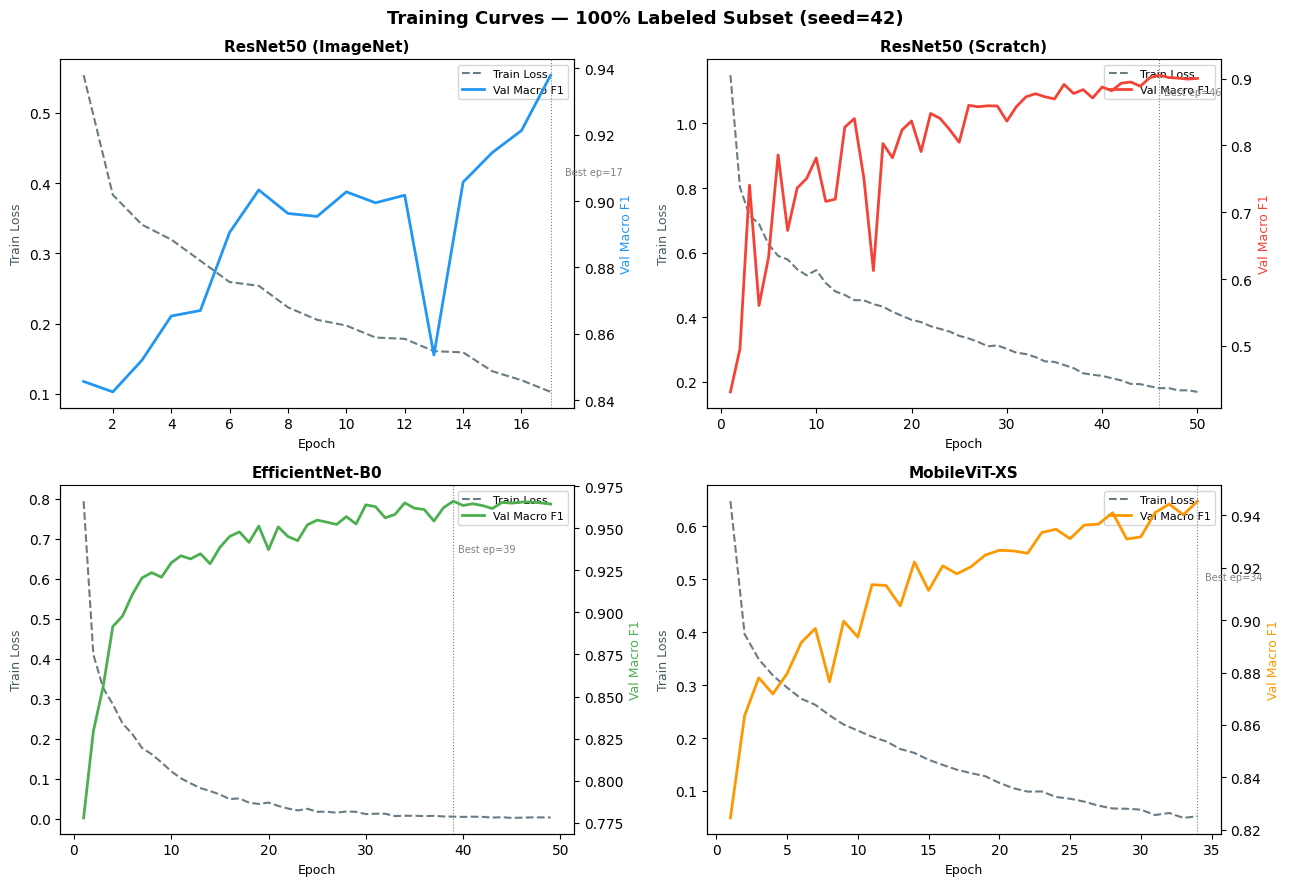

  Saved (combined): /content/drive/MyDrive/MedSSL_Research/figures/training_curves_100pct.png
  Saved (individual): /content/drive/MyDrive/MedSSL_Research/figures/individual/training_curve_resnet50_pretrained.png
  Saved (individual): /content/drive/MyDrive/MedSSL_Research/figures/individual/training_curve_resnet50_scratch.png
  Saved (individual): /content/drive/MyDrive/MedSSL_Research/figures/individual/training_curve_efficientnet_b0.png
  Saved (individual): /content/drive/MyDrive/MedSSL_Research/figures/individual/training_curve_mobilevit_xs.png


In [16]:

# ════════════════════════════════════════════════════════════
# FIGURE A — Training Curves
# Saves: training_curves_100pct.png          (2x2 combined)
#        individual/training_curve_{model}.png (one per model)
# ════════════════════════════════════════════════════════════

print('Figure A: Training curves ...')

def plot_training_curve(ax, mn, r):
    """Plot train loss + val F1 on a dual-axis for one model."""
    epochs  = list(range(1, len(r['train_losses']) + 1))
    ax2     = ax.twinx()

    ax.plot(epochs, r['train_losses'], color='#455A64', linewidth=1.5,
            label='Train Loss', linestyle='--', alpha=0.8)
    ax2.plot(epochs, r['val_f1s'], color=MODEL_COLORS[mn], linewidth=2.0,
             label='Val Macro F1')

    best_ep = r['best_epoch']
    ax2.axvline(best_ep, color='gray', linewidth=0.8, linestyle=':')
    ax2.annotate(f'Best ep={best_ep}', xy=(best_ep, r['best_val_f1']),
                 fontsize=7, color='gray', ha='left',
                 xytext=(best_ep + 0.5, r['best_val_f1'] - 0.03))

    ax.set_xlabel('Epoch', fontsize=9)
    ax.set_ylabel('Train Loss', fontsize=9, color='#455A64')
    ax2.set_ylabel('Val Macro F1', fontsize=9, color=MODEL_COLORS[mn])
    ax.set_title(MODEL_LABELS[mn], fontsize=11, fontweight='bold')

    lines1, labs1 = ax.get_legend_handles_labels()
    lines2, labs2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labs1 + labs2, fontsize=8, loc='upper right')
    ax.spines['top'].set_visible(False)
    return ax2


# Combined 2x2
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()
for ax, mn in zip(axes, MODELS):
    path = f'{CONFIG["results_dir"]}/{mn}_100pct_seed42.json'
    if not os.path.exists(path):
        ax.set_title(f'{MODEL_LABELS[mn]}\n(no data)', fontsize=10)
        continue
    with open(path) as f:
        r = json.load(f)
    plot_training_curve(ax, mn, r)

fig.suptitle('Training Curves — 100% Labeled Subset (seed=42)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
path_a = f'{FIGS_DIR}/training_curves_100pct.png'
plt.savefig(path_a, dpi=FIG_DPI, bbox_inches='tight')
plt.show()
print(f'  Saved (combined): {path_a}')

# Individual — one per model
for mn in MODELS:
    path = f'{CONFIG["results_dir"]}/{mn}_100pct_seed42.json'
    if not os.path.exists(path):
        print(f'  [SKIP] No data for {mn}')
        continue
    with open(path) as f:
        r = json.load(f)
    fig, ax = plt.subplots(figsize=(7, 5))
    plot_training_curve(ax, mn, r)
    fig.suptitle(f'Training Curve — {MODEL_LABELS[mn]}\n100% Labels, seed=42',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    out = f'{FIGS_DIR}/individual/training_curve_{mn}.png'
    plt.savefig(out, dpi=FIG_DPI, bbox_inches='tight')
    plt.close()
    print(f'  Saved (individual): {out}')




Figure B: Confusion matrices ...


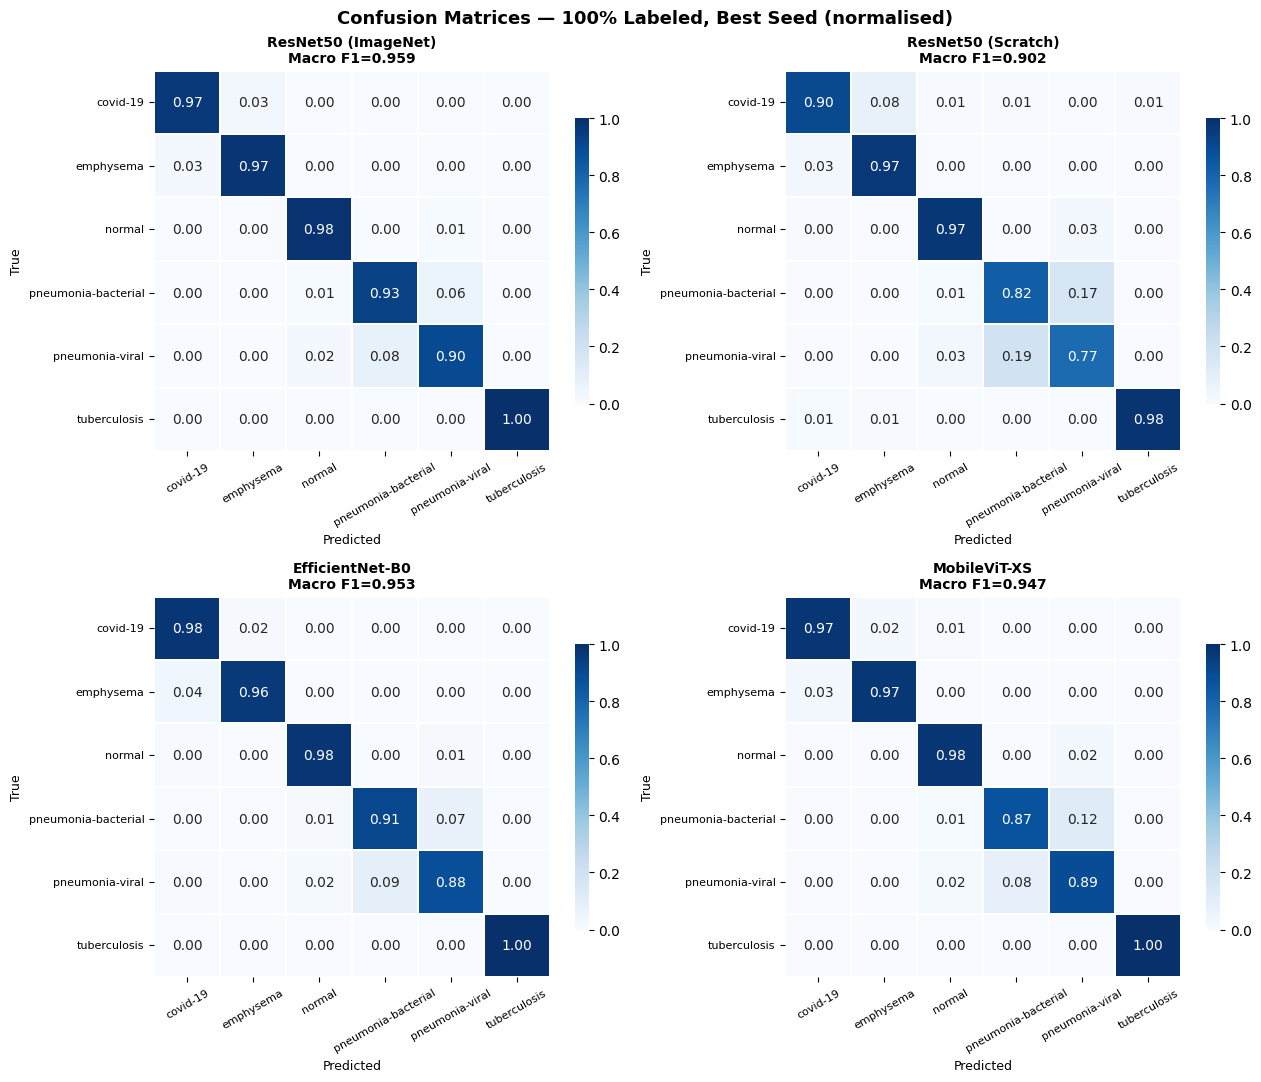

  Saved (combined): /content/drive/MyDrive/MedSSL_Research/figures/confusion_matrices_supervised.png
  Saved (individual): /content/drive/MyDrive/MedSSL_Research/figures/individual/confusion_matrix_resnet50_pretrained.png
  Saved (individual): /content/drive/MyDrive/MedSSL_Research/figures/individual/confusion_matrix_resnet50_scratch.png
  Saved (individual): /content/drive/MyDrive/MedSSL_Research/figures/individual/confusion_matrix_efficientnet_b0.png
  Saved (individual): /content/drive/MyDrive/MedSSL_Research/figures/individual/confusion_matrix_mobilevit_xs.png


In [17]:

# ════════════════════════════════════════════════════════════
# FIGURE B — Confusion Matrices
# Saves: confusion_matrices_supervised.png       (2x2 combined)
#        individual/confusion_matrix_{model}.png  (one per model)
# ════════════════════════════════════════════════════════════

print('\nFigure B: Confusion matrices ...')

def get_best_seed_result(model_name, subset_name, all_results):
    """Return result dict for the seed with highest test macro F1."""
    group = [r for r in all_results
             if r['model_name'] == model_name and r['subset_name'] == subset_name]
    if not group:
        return None
    return max(group, key=lambda r: r['test_metrics']['macro_f1'])


def plot_confusion_matrix(ax, mn, res):
    """Plot normalised confusion matrix heatmap for one model."""
    cm      = np.array(res['test_metrics']['conf_matrix'])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    short_names = [c.replace('Pneumonia-', 'Pneu-')
                    .replace('Covid-19', 'Covid')
                   for c in CONFIG['class_names']]

    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=short_names, yticklabels=short_names,
                ax=ax, cbar_kws={'shrink': 0.75}, linewidths=0.3,
                vmin=0, vmax=1)
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('True', fontsize=9)
    ax.set_title(f'{MODEL_LABELS[mn]}\nMacro F1={res["test_metrics"]["macro_f1"]:.3f}',
                 fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.tick_params(axis='y', rotation=0,  labelsize=8)


# Combined 2x2
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
axes = axes.flatten()
for ax, mn in zip(axes, MODELS):
    res = get_best_seed_result(mn, '100pct', all_results)
    if res is None:
        ax.set_title(f'{MODEL_LABELS[mn]}\n(no data)', fontsize=10)
        continue
    plot_confusion_matrix(ax, mn, res)

fig.suptitle('Confusion Matrices — 100% Labeled, Best Seed (normalised)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
path_b = f'{FIGS_DIR}/confusion_matrices_supervised.png'
plt.savefig(path_b, dpi=FIG_DPI, bbox_inches='tight')
plt.show()
print(f'  Saved (combined): {path_b}')

# Individual — one per model
for mn in MODELS:
    res = get_best_seed_result(mn, '100pct', all_results)
    if res is None:
        print(f'  [SKIP] No data for {mn}')
        continue
    fig, ax = plt.subplots(figsize=(6, 5))
    plot_confusion_matrix(ax, mn, res)
    fig.suptitle(f'Confusion Matrix — {MODEL_LABELS[mn]}\n100% Labels, Best Seed',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    out = f'{FIGS_DIR}/individual/confusion_matrix_{mn}.png'
    plt.savefig(out, dpi=FIG_DPI, bbox_inches='tight')
    plt.close()
    print(f'  Saved (individual): {out}')


Figure C: Performance vs labeled data ...


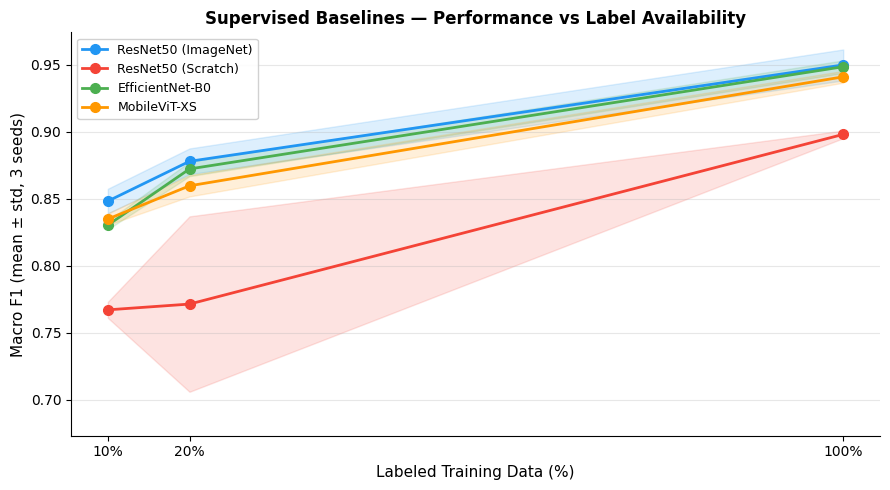

  Saved: /content/drive/MyDrive/MedSSL_Research/figures/perf_vs_labels_supervised.png
  (Will be updated in NB3 to add SSL model lines.)


In [18]:

# ════════════════════════════════════════════════════════════
# FIGURE C — Performance vs Label Availability
# Saves: perf_vs_labels_supervised.png  (single figure, no split needed)
# ════════════════════════════════════════════════════════════

print('\nFigure C: Performance vs labeled data ...')
SUBSET_X    = [10, 20, 100]
SUBSET_KEYS = ['10pct', '20pct', '100pct']

fig, ax = plt.subplots(figsize=(9, 5))
for mn in MODELS:
    means, stds = [], []
    for sn in SUBSET_KEYS:
        group = [r for r in all_results
                 if r['model_name'] == mn and r['subset_name'] == sn]
        f1s = [r['test_metrics']['macro_f1'] for r in group]
        means.append(np.mean(f1s) if f1s else np.nan)
        stds.append(np.std(f1s)  if f1s else np.nan)

    means = np.array(means)
    stds  = np.array(stds)
    ax.plot(SUBSET_X, means, marker='o', label=MODEL_LABELS[mn],
            color=MODEL_COLORS[mn], linewidth=2, markersize=7)
    ax.fill_between(SUBSET_X, means - stds, means + stds,
                    alpha=0.15, color=MODEL_COLORS[mn])

ax.set_xlabel('Labeled Training Data (%)', fontsize=11)
ax.set_ylabel('Macro F1 (mean ± std, 3 seeds)', fontsize=11)
ax.set_title('Supervised Baselines — Performance vs Label Availability',
             fontsize=12, fontweight='bold')
ax.set_xticks(SUBSET_X)
ax.set_xticklabels(['10%', '20%', '100%'])
ax.legend(fontsize=9, framealpha=0.9)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(bottom=max(0, ax.get_ylim()[0] - 0.02))
plt.tight_layout()
path_c = f'{FIGS_DIR}/perf_vs_labels_supervised.png'
plt.savefig(path_c, dpi=FIG_DPI, bbox_inches='tight')
plt.show()
print(f'  Saved: {path_c}')
print('  (Will be updated in NB3 to add SSL model lines.)')


### Status Summary  

In [19]:

import os, json
import numpy as np

# Count completed runs
completed_runs = sum(
    1 for mn in MODELS for sn in SUBSETS for sd in SEEDS
    if os.path.exists(f'{CONFIG["results_dir"]}/{mn}_{sn}_seed{sd}.json')
)

# Best model at 10% labels
def best_model_at(subset_name, all_results):
    best_f1, best_name = 0.0, 'N/A'
    for mn in MODELS:
        group = [r for r in all_results
                 if r['model_name'] == mn and r['subset_name'] == subset_name]
        if not group: continue
        mean_f1 = np.mean([r['test_metrics']['macro_f1'] for r in group])
        if mean_f1 > best_f1:
            best_f1, best_name = mean_f1, mn
    return best_name, best_f1

best10_name, best10_f1   = best_model_at('10pct',  all_results)
best100_name, best100_f1 = best_model_at('100pct', all_results)

# Check checkpoints
ckpt_dir    = f'{CONFIG["ckpt_dir"]}/supervised'
n_ckpts     = len([f for f in os.listdir(ckpt_dir) if f.endswith('.pt')]) \
              if os.path.isdir(ckpt_dir) else 0

# Check figures
fig_files = ['training_curves_100pct.png',
             'confusion_matrices_supervised.png',
             'perf_vs_labels_supervised.png']
figs_ok = all(os.path.exists(f'{FIGS_DIR}/{f}') for f in fig_files)

W = 45
print('=' * (W + 15))
print('  NOTEBOOK 2 — STATUS SUMMARY')
print('=' * (W + 15))
print(f'  {"Runs completed":<{W}} {completed_runs} / {len(MODELS)*len(SUBSETS)*len(SEEDS)}')
print(f'  {"Best model @ 10% labels":<{W}} {best10_name}  (F1={best10_f1:.4f})')
print(f'  {"Best model @ 100% labels":<{W}} {best100_name}  (F1={best100_f1:.4f})')
print(f'  {"Checkpoints saved":<{W}} {n_ckpts} .pt files')
print(f'  {"Results CSV saved":<{W}} supervised_results_summary.csv')
print(f'  {"Figures saved (3)":<{W}} {"OK" if figs_ok else "SOME MISSING"}')
print()
print(f'  {"STATUS":<{W}} {"READY FOR NOTEBOOK 3" if completed_runs == 36 else "INCOMPLETE — re-run Cell 5"}')
print('=' * (W + 15))

  NOTEBOOK 2 — STATUS SUMMARY
  Runs completed                                36 / 36
  Best model @ 10% labels                       resnet50_pretrained  (F1=0.8481)
  Best model @ 100% labels                      resnet50_pretrained  (F1=0.9497)
  Checkpoints saved                             39 .pt files
  Results CSV saved                             supervised_results_summary.csv
  Figures saved (3)                             OK

  STATUS                                        READY FOR NOTEBOOK 3


### Inference latency + DRS timing (R2-2)

In [22]:
import time, timeit

ALL_MODEL_KEYS = ['resnet50_pretrained', 'resnet50_scratch',
                   'efficientnet_b0', 'mobilevit_xs',
                   'simclr_resnet50', 'mae_vits16']

def build_full_model_for_timing(model_name, num_classes=6):
    if model_name in ('resnet50_pretrained', 'resnet50_scratch',
                       'efficientnet_b0', 'mobilevit_xs'):
        model, _, _ = build_model(model_name, num_classes)
    elif model_name == 'simclr_resnet50':
        backbone = tvm.resnet50(weights=None); backbone.fc = nn.Identity()
        model = nn.Sequential(backbone, nn.Linear(2048, num_classes))
    elif model_name == 'mae_vits16':
        backbone = timm.create_model('vit_small_patch16_224', pretrained=False, num_classes=0)
        model = nn.Sequential(backbone, nn.Linear(backbone.num_features, num_classes))
    return model.to(DEVICE).eval()

def time_inference(model, batch_size=1, n_warmup=10, n_timed=100, mc_passes=1):
    x = torch.randn(batch_size, 3, 224, 224, device=DEVICE)
    with torch.no_grad():
        for _ in range(n_warmup):
            for _ in range(mc_passes): _ = model(x)
        if DEVICE.type == 'cuda': torch.cuda.synchronize()
        t0 = time.time()
        for _ in range(n_timed):
            for _ in range(mc_passes): _ = model(x)
        if DEVICE.type == 'cuda': torch.cuda.synchronize()
        t1 = time.time()
    return (t1 - t0) / n_timed * 1000  # ms

print(f'{"Model":<28} {"Single-image (ms)":>20} {"MC-Dropout x20 (ms)":>22}')
timing_rows = []
for mn in ALL_MODEL_KEYS:
    model = build_full_model_for_timing(mn)
    single_ms = time_inference(model, mc_passes=1)
    mc20_ms   = time_inference(model, mc_passes=20)
    print(f'{MODEL_LABELS.get(mn, mn):<28} {single_ms:>20.2f} {mc20_ms:>22.2f}')
    timing_rows.append({'Model': MODEL_LABELS.get(mn, mn), 'model_key': mn,
                         'single_image_ms': round(single_ms,2), 'mc_dropout_20pass_ms': round(mc20_ms,2)})
    del model
    if DEVICE.type == 'cuda': torch.cuda.empty_cache()

pd.DataFrame(timing_rows).to_csv(f'{CONFIG["results_dir"]}/inference_timing.csv', index=False)

drs_time_us = timeit.timeit(lambda: 0.30 * 95.2 + 0.70 * (100 - 3.13), number=100000) / 100000 * 1e6
print(f'\nDRS scalar computation: {drs_time_us:.3f} microseconds per call (negligible)')

Model                           Single-image (ms)    MC-Dropout x20 (ms)
  resnet50_pretrained           23.5M params  backbone_p=23.5M  head_p=0.0M
ResNet50 (ImageNet)                          5.81                 127.33
  resnet50_scratch              23.5M params  backbone_p=23.5M  head_p=23.5M
ResNet50 (Scratch)                           5.78                 124.49
  efficientnet_b0               4.0M params  backbone_p=4.0M  head_p=0.0M
EfficientNet-B0                              7.91                 174.26
  mobilevit_xs                  1.9M params  backbone_p=1.9M  head_p=0.0M
MobileViT-XS                                11.65                 181.54
simclr_resnet50                              5.85                 127.09
mae_vits16                                   5.68                 115.32

DRS scalar computation: 0.032 microseconds per call (negligible)
